# TP 4 : Steam Games Self Agentic BI service (Mistral AI + DuckDB)
---
---

## Partie 1 - Configuration et Installation
---

Dans ce TP, nous utilisons :
- **DuckDB** : Base de données locale, rapide et sans serveur
- **Mistral AI API** : Pour la génération de requêtes SQL et configurations de graphiques

### Configuration initiale

#### Fichiers requis pour ce TP

Ce notebook nécessite des données dans le dossier Steam Data : C:\Users\<USER>\Documents\avisia-llm-formation\Steam_data :

1. **`Steam_data/`** : Contient les fichiers CSV de données Steam
   - `games.csv`
   - `t-games-categories.csv`
   - `t-games-tags.csv`

Pour cela nous allons créer le dossier avec du langage Bash dans Colab

In [15]:
!mkdir Steam_data

Dans Google Colab :

1. Utilisez le menu latéral de Colab (📁 Files)
2. Cliquez dans le dossier Steam_data
2. Uploadez manuellement les fichiers dans ce dernier à partir de l'emplacement local : .\Documents\avisia-llm-formation\Steam_data

In [16]:
# Installation des dépendances
!pip install -q duckdb pandas mistralai sqlalchemy seaborn matplotlib gradio

print("✅ Dépendances installées avec succès!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.8/442.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.3/160.3 kB 13.2 MB/s eta 0:00:00
✅ Dépendances installées avec succès!


## Partie 2 - Préparer votre base de données DuckDB locale
---

##### Données source
Les tables sont stockées au format **CSV** dans le dossier **Steam_data** et seront importées dans **DuckDB**.

Fichiers :
- `Steam_data/games.csv`
- `Steam_data/t-games-categories.csv`
- `Steam_data/t-games-tags.csv`


##### Création de la base DuckDB
Nous allons :

1️⃣ **Charger les fichiers CSV** depuis le dossier local Steam_data

2️⃣ **Créer une base DuckDB locale** avec les trois tables

3️⃣ **Enrichir le schéma** avec des descriptions pour aider le LLM

**DuckDB** est une base de données SQL embarquée, rapide et sans serveur, idéale pour l'analytique de données.

In [19]:
import duckdb
import pandas as pd
import os

# Définir le chemin vers le dossier Steam_data
DATA_FOLDER = "Steam_data"

# Vérifier que le dossier existe
if not os.path.exists(DATA_FOLDER):
    raise Exception(f"❌ Le dossier '{DATA_FOLDER}' n'existe pas. Assurez-vous que les fichiers CSV sont présents.")

# Définir les chemins des fichiers CSV
csv_files = {
    "games": os.path.join(DATA_FOLDER, "games.csv"),
    "t_games_categories": os.path.join(DATA_FOLDER, "t-games-categories.csv"),
    "t_games_tags": os.path.join(DATA_FOLDER, "t-games-tags.csv")
}

# Vérifier que tous les fichiers existent
print("📂 Vérification des fichiers CSV...")
for table_name, file_path in csv_files.items():
    if os.path.exists(file_path):
        file_size = os.path.getsize(file_path) / (1024 * 1024)  # Taille en MB
        print(f"  ✅ {file_path} ({file_size:.2f} MB)")
    else:
        raise Exception(f"❌ Fichier manquant: {file_path}")

print("\n✅ Tous les fichiers CSV sont présents!")

📂 Vérification des fichiers CSV...
  ✅ Steam_data/games.csv (3.44 MB)
  ✅ Steam_data/t-games-categories.csv (4.75 MB)
  ✅ Steam_data/t-games-tags.csv (15.54 MB)

✅ Tous les fichiers CSV sont présents!


In [20]:
# Créer la base de données DuckDB et importer les CSV
conn = duckdb.connect('steam_games.db')

print("🗄️ Création de la base de données DuckDB...\n")

# Table games
print("📥 Importation de la table 'games'...")
conn.execute(f"""
    CREATE OR REPLACE TABLE games AS
    SELECT * FROM read_csv_auto('{csv_files["games"]}')
""")
print("  ✅ Table 'games' créée")

# Table t_games_categories
print("📥 Importation de la table 't_games_categories'...")
conn.execute(f"""
    CREATE OR REPLACE TABLE t_games_categories AS
    SELECT * FROM read_csv_auto('{csv_files["t_games_categories"]}')
""")
print("  ✅ Table 't_games_categories' créée")

# Table t_games_tags
print("📥 Importation de la table 't_games_tags'...")
conn.execute(f"""
    CREATE OR REPLACE TABLE t_games_tags AS
    SELECT * FROM read_csv_auto('{csv_files["t_games_tags"]}')
""")
print("  ✅ Table 't_games_tags' créée")

print("\n✅ Base de données DuckDB créée avec succès!")

# Vérifier les tables
print("\n📊 Tables créées:")
tables_df = conn.execute("SHOW TABLES").fetchdf()
print(tables_df)

# Afficher le nombre de lignes par table
print("\n📊 Nombre de lignes par table:")
for table in ["games", "t_games_categories", "t_games_tags"]:
    count = conn.execute(f"SELECT COUNT(*) as count FROM {table}").fetchdf()['count'][0]
    print(f"  • {table}: {count:,} lignes")

🗄️ Création de la base de données DuckDB...

📥 Importation de la table 'games'...
  ✅ Table 'games' créée
📥 Importation de la table 't_games_categories'...
  ✅ Table 't_games_categories' créée
📥 Importation de la table 't_games_tags'...
  ✅ Table 't_games_tags' créée

✅ Base de données DuckDB créée avec succès!

📊 Tables créées:
                 name
0               games
1  t_games_categories
2        t_games_tags

📊 Nombre de lignes par table:
  • games: 60,952 lignes
  • t_games_categories: 210,520 lignes
  • t_games_tags: 777,401 lignes


### Documentation des champs (Métadonnées)

DuckDB ne supporte pas nativement les descriptions de colonnes dans le schéma, cependant, d'autres bases de données ont cette feature permettant d'ajouter une description aux différentes colonnes d'une table.
Pour pallier à ce défaut de DuckDB, nous allons créer un **dictionnaire de métadonnées** qui sera utilisé par le LLM.


In [23]:
# Définir les métadonnées manuellement pour aider le LLM
TABLE_METADATA = {
    "games": {
        "name": "Game title",
        "release_date": "Date the game was published",
        "price": "Price in USD",
        "positive": "Number of positive reviews",
        "negative": "Number of negative reviews",
        "app_id": "Unique ID for games",
        "min_owners": "Estimated sales (minimum), from SteamSpy",
        "max_owners": "Estimated sales (maximum), from SteamSpy",
        "hltb_single": "Game duration in hours, from HowLongToBeat"
    },
    "t_games_categories": {
        "app_id": "Unique ID for games",
        "categories": "Game features (e.g., Single-player, Multiplayer, Co-op)"
    },
    "t_games_tags": {
        "app_id": "Unique ID for games",
        "tags": "User-defined tags (e.g., Action, RPG, Strategy)",
        "tag_frequencies": "Number of user votes for a tag in a game"
    }
}

print("✅ Métadonnées définies pour aider le LLM")

✅ Métadonnées définies pour aider le LLM


## Partie 3 - Explorer les tables avec Pandas et DuckDB
---

##### Exploration des données avec Pandas
DuckDB s'intègre parfaitement avec Pandas. Nous pouvons exécuter des requêtes SQL et obtenir directement des DataFrames.

In [24]:
# Explorer la table games
df_games = conn.execute("SELECT * FROM games").fetchdf()

print(f"Nombre de lignes: {df_games.shape}")
print(f"Période du dataset de {df_games.release_date.min()} à {df_games.release_date.max()}")
df_games.head()

Nombre de lignes: (60952, 9)
Période du dataset de 2013-01-07 00:00:00 à 2023-11-30 00:00:00


,name,release_date,price,positive,negative,app_id,min_owners,max_owners,hltb_single
0,Train Bandit,2017-10-12,0.99,53,5,655370,0,20000,NaN
1,Henosis™,2020-07-23,5.99,3,0,1355720,0,20000,NaN
2,Two Weeks in Painland,2020-02-03,0.00,50,8,1139950,0,20000,NaN
3,Wartune Reborn,2021-02-26,0.00,87,49,1469160,50000,100000,NaN
4,TD Worlds,2022-01-09,10.99,21,7,1659180,0,20000,NaN


In [25]:
# Explorer la table t_games_categories
df_categories = conn.execute("SELECT * FROM t_games_categories").fetchdf()

print(f"Nombre de lignes: {df_categories.shape}")
print("\n📊 Distribution des catégories (Top 10):")
print(df_categories.categories.value_counts().head(10))

Nombre de lignes: (210520, 2)

📊 Distribution des catégories (Top 10):
categories
Single-player                 58112
Steam Achievements            30650
Steam Cloud                   16086
Full controller support       13634
Multi-player                  12103
Steam Trading Cards            9412
Partial Controller Support     8490
PvP                            7715
Co-op                          6193
Steam Leaderboards             5809
Name: count, dtype: int64


In [26]:
# Explorer la table t_games_tags
df_tags = conn.execute("SELECT * FROM t_games_tags").fetchdf()

print(f"Nombre de lignes: {df_tags.shape}")
print("\n📊 Tags les plus populaires (Top 10):")
print(df_tags.tags.value_counts().head(10))

Nombre de lignes: (777401, 3)

📊 Tags les plus populaires (Top 10):
tags
Indie           39433
Singleplayer    31696
Action          27666
Casual          26771
Adventure       25954
2D              17031
Strategy        13008
Simulation      12960
RPG             11554
Puzzle          10925
Name: count, dtype: int64


## Partie 4 - Créer un système d'agents IA pour interroger DuckDB avec Mistral AI
---

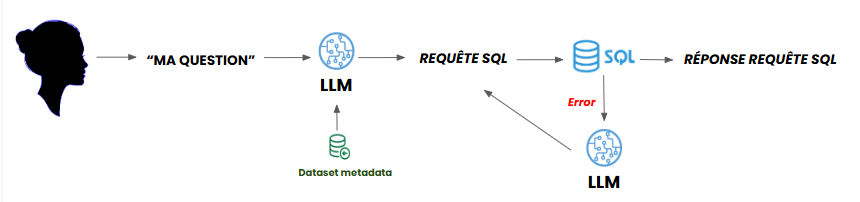

#### 🤖 Création du système d'agent IA avec Mistral AI

Dans cette section, nous allons créer un agent IA capable de :
- Comprendre une question en langage naturel
- Générer une requête SQL DuckDB
- Exécuter la requête et retourner les résultats

In [31]:
import json
import os
from mistralai import Mistral

# Configuration de la clé API Mistral
MISTRAL_API_KEY = input('Entrez votre clé API Mistral: ')

# Initialisation du client Mistral
mistral_client = Mistral(api_key=MISTRAL_API_KEY)

Entrez votre clé API Mistral: Tbrznmx7kNMLRKs9DQbpQSUqYwL3Cx85


In [32]:
# Générer le schéma enrichi pour le LLM
def get_schema_info():
    """Génère une description complète du schéma de la base de données pour le LLM."""
    schema_info = []

    for table_name in ["games", "t_games_categories", "t_games_tags"]:
        # Récupérer les colonnes et types
        columns_info = conn.execute(f"DESCRIBE {table_name}").fetchdf()

        columns = []
        for _, row in columns_info.iterrows():
            col_name = row['column_name']
            col_type = row['column_type']
            description = TABLE_METADATA.get(table_name, {}).get(col_name, "")

            columns.append({
                col_name: {
                    "type": col_type,
                    "description": description
                }
            })

        schema_info.append({
            "table_name": table_name,
            "columns": columns
        })

    return schema_info

schema_info = get_schema_info()
print(f"Schéma de la base de données:\n{json.dumps(schema_info, indent=2)}")

Schéma de la base de données:
[
  {
    "table_name": "games",
    "columns": [
      {
        "name": {
          "type": "VARCHAR",
          "description": "Game title"
        }
      },
      {
        "release_date": {
          "type": "DATE",
          "description": "Date the game was published"
        }
      },
      {
        "price": {
          "type": "DOUBLE",
          "description": "Price in USD"
        }
      },
      {
        "positive": {
          "type": "BIGINT",
          "description": "Number of positive reviews"
        }
      },
      {
        "negative": {
          "type": "BIGINT",
          "description": "Number of negative reviews"
        }
      },
      {
        "app_id": {
          "type": "BIGINT",
          "description": "Unique ID for games"
        }
      },
      {
        "min_owners": {
          "type": "BIGINT",
          "description": "Estimated sales (minimum), from SteamSpy"
        }
      },
      {
        "max_owners":

### Préparer un TOOL Mistral AI pour la génération SQL

Mistral AI supporte le **function calling** permettant d'appeler des outils (https://docs.mistral.ai/capabilities/function_calling).
Nous allons créer un outil qui force le LLM à retourner :
- `query` : La requête SQL DuckDB générée
- `type` : Le type de requête (SELECT, INSERT, etc.)

🚨 **Sécurité** : Nous n'autorisons que les requêtes `SELECT` pour éviter toute modification de données.

In [33]:
query_database_tool = {
    "type": "function",
    "function": {
        "name": "query_database",
        "description": "Create a DuckDB SQL query which answers the question as accurately as possible. Make sure to return a complete query, without the user needing to add additional information. Also return the type of the query, like 'SELECT', 'INSERT', 'UPDATE', 'DELETE', etc.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "description": "DuckDB SQL query"
                },
                "type": {
                    "type": "string",
                    "description": "Type of query: 'SELECT', 'INSERT', 'UPDATE', 'DELETE', etc."
                }
            },
            "required": ["query", "type"]
        }
    }
}

### Créer l'agent qui génère les requêtes SQL avec Mistral AI

In [34]:
def create_query(question: str, schema):
    """
    Génère une requête SQL DuckDB en fonction d'une question utilisateur et du schéma de la base de données.
    Utilise Mistral AI pour créer une requête complète.
    """

    system_prompt = f"""Given the following DuckDB database schema, create a SQL query which answers the user's question as accurately as possible.
Make sure to return a complete query, without the user needing to add additional information.
Also return the type of the query, like 'SELECT', 'INSERT', 'UPDATE', 'DELETE', etc.

Database Schema:
{json.dumps(schema, indent=2)}

Important notes:
- Use DuckDB SQL syntax
- For date filtering, use DATE type comparison
- Column names are case-sensitive
- Use proper JOIN syntax when combining tables"""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": question}
    ]

    response = mistral_client.chat.complete(
        model="mistral-large-latest",
        messages=messages,
        tools=[query_database_tool],
        tool_choice="any",
        temperature=0
    )

    # Afficher la réponse complète
    print("\n📝 Réponse Mistral AI:")
    print(json.dumps(response.model_dump(), indent=2, default=str))

    # Extraire la requête SQL
    if response.choices[0].message.tool_calls:
        tool_call = response.choices[0].message.tool_calls[0]
        arguments = json.loads(tool_call.function.arguments)
        query = arguments["query"]
        query_type = arguments["type"]

        # Sécurité : autoriser uniquement SELECT
        if query_type.upper() != "SELECT":
            raise Exception("⛔ Only SELECT statements are allowed!")

        return query
    else:
        raise Exception("❌ No query generated by the model")

### Créer l'agent qui gère les erreurs SQL

In [35]:
def error_handling(question: str, query: str, schema, error):
    """
    Corrige une requête SQL DuckDB qui a échoué.
    Utilise Mistral AI pour analyser l'erreur et générer une version corrigée.
    """

    system_prompt = f"""Given the following DuckDB database schema, you suggested a SQL query to answer the following question which resulted in an error.
Please analyze the error and correct the query.

Database Schema:
{json.dumps(schema, indent=2)}

Original question: {question}
Your previous query (which failed): {query}
Error message: {str(error)}

Please correct the error and provide a working DuckDB SQL query."""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": "Correct the error and answer the question."}
    ]

    response = mistral_client.chat.complete(
        model="mistral-large-latest",
        messages=messages,
        tools=[query_database_tool],
        tool_choice="any",
        temperature=0
    )

    # Extraire la requête corrigée
    if response.choices[0].message.tool_calls:
        tool_call = response.choices[0].message.tool_calls[0]
        arguments = json.loads(tool_call.function.arguments)
        return arguments["query"]
    else:
        raise Exception("❌ No corrected query generated")

### 🏗️ Exécution du système d'agent SQL avec DuckDB

In [36]:
def execute_agent(question: str):
    """
    Exécute un agent IA pour générer et exécuter une requête SQL DuckDB.
    L'agent tente de corriger les erreurs SQL jusqu'à 10 fois avant d'abandonner.
    """

    # Génération initiale de la requête SQL
    query = create_query(question, schema_info)
    print(f"\n✅ Requête générée: {query}\n")

    runs = 0
    while runs < 10:
        try:
            # Exécution de la requête SQL avec DuckDB
            result = conn.execute(query).fetchdf()
            print(f"✅ Requête exécutée avec succès! ({len(result)} lignes retournées)")
            return result
        except Exception as e:
            print(f"\n❌ Erreur lors de l'exécution: {e}")
            print("🔄 Tentative de correction...\n")

            # Correction de la requête
            query = error_handling(question, query, schema_info, e)
            print(f"🔧 Nouvelle requête générée: {query}\n")

            runs += 1

    # Échec après 10 tentatives
    print("⛔ Arrêt de l'agent après 10 tentatives échouées.")
    return None

### 🎯 Tester le système d'agents SQL

In [37]:
MA_QUESTION = "Quel est le jeu vidéo avec le plus de commentaires positifs entre 2015 et 2020?"

df_result = execute_agent(MA_QUESTION)
df_result


📝 Réponse Mistral AI:
{
  "id": "c53095cadef549c9af713ee4ec614cc4",
  "object": "chat.completion",
  "model": "mistral-large-latest",
  "usage": {
    "prompt_tokens": 814,
    "completion_tokens": 85,
    "total_tokens": 899
  },
  "created": 1765236542,
  "choices": [
    {
      "index": 0,
      "message": {
        "content": "",
        "tool_calls": [
          {
            "function": {
              "name": "query_database",
              "arguments": "{\"query\": \"SELECT g.name AS game_title, g.positive AS positive_reviews, g.release_date\\nFROM games g\\nWHERE g.release_date BETWEEN DATE '2015-01-01' AND DATE '2020-12-31'\\nORDER BY g.positive DESC\\nLIMIT 1;\", \"type\": \"SELECT\"}"
            },
            "id": "k232bcXGN",
            "type": null,
            "index": 0
          }
        ],
        "prefix": false,
        "role": "assistant"
      },
      "finish_reason": "tool_calls"
    }
  ]
}

✅ Requête générée: SELECT g.name AS game_title, g.positive AS p

,game_title,positive_reviews,release_date
0,Grand Theft Auto V,1171197,2015-04-13


In [ ]:
# Autre exemple de question
MA_QUESTION = "Quels sont les 10 jeux les plus chers du dataset?"

df_result = execute_agent(MA_QUESTION)
df_result

## Partie 5 - Créer un système d'agents IA pour visualiser les données
---

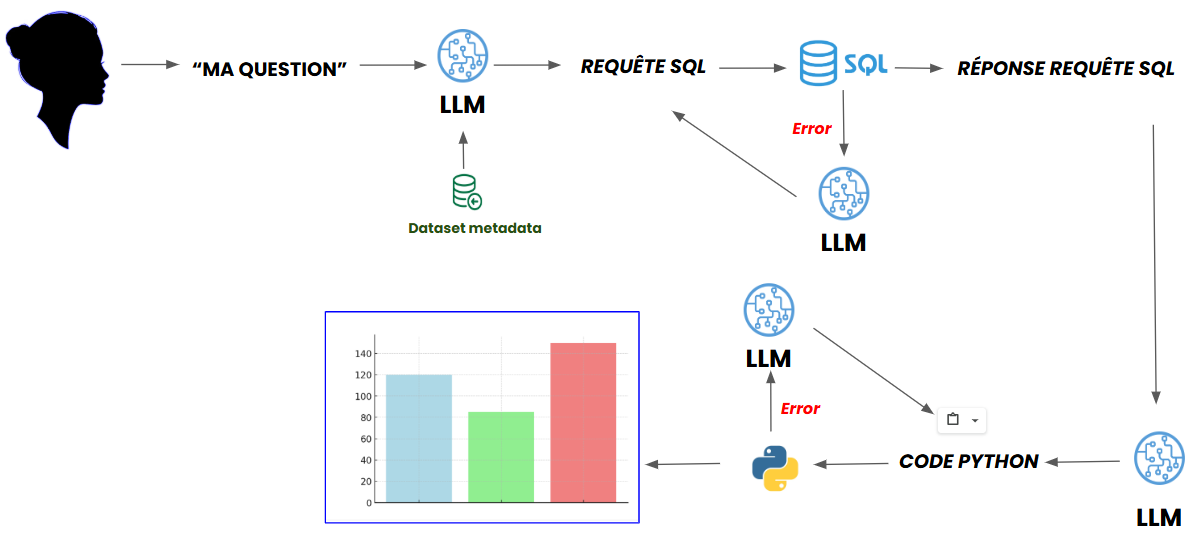



### Consignes

Nous allons créer un agent qui génère automatiquement des visualisations avec Seaborn.

##### 🎨 Librairie Seaborn

**Seaborn** est un package python qui permet de créer facilement des graphiques statistiques élégants.

##### 📊 Types de graphiques disponibles :
- **barplot** : Graphique en barres
- **lineplot** : Courbe
- **scatterplot** : Nuage de points
- **boxplot** : Boîte à moustaches
- **violinplot** : Violin plot
- **histplot** : Histogramme

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

### Définir le TOOL pour la génération de configuration de graphiques

In [ ]:
graph_tool = {
    "type": "function",
    "function": {
        "name": "generate_plot_config",
        "description": "Generate a Seaborn plot configuration to visualize data based on a user question. Choose the most appropriate plot type (bar, scatter, line, hist, box, violin) and specify the columns for x, y axes and optional hue parameter.",
        "parameters": {
            "type": "object",
            "properties": {
                "plot_type": {
                    "type": "string",
                    "description": "Type of Seaborn plot: 'bar', 'scatter', 'line', 'hist', 'box', 'violin'"
                },
                "x": {
                    "type": "string",
                    "description": "Column name for the x-axis"
                },
                "y": {
                    "type": "string",
                    "description": "Column name for the y-axis"
                },
                "hue": {
                    "type": ["string", "null"],
                    "description": "Optional column for color grouping"
                },
                "title": {
                    "type": "string",
                    "description": "Title for the plot"
                },
                "other_params": {
                    "type": "object",
                    "description": "Additional Seaborn parameters (palette, etc.)"
                }
            },
            "required": ["plot_type", "x", "y", "title"]
        }
    }
}

### Fonction pour générer le graphique avec Seaborn

In [ ]:
def plot_graph(data, graph_config):
    """
    Génère un graphique Seaborn à partir des paramètres fournis.
    """
    plot_type = graph_config.get("plot_type")
    x = graph_config.get("x")
    y = graph_config.get("y")
    hue = graph_config.get("hue")
    title = graph_config.get("title", "Visualisation des données")
    other_params = graph_config.get("other_params", {})

    palette = other_params.pop("palette", "viridis")

    try:
        plt.figure(figsize=(12, 6))

        # Sélection du type de graphique
        if plot_type == "bar":
            sns.barplot(data=data, x=x, y=y, hue=hue, palette=palette, **other_params)
        elif plot_type == "scatter":
            sns.scatterplot(data=data, x=x, y=y, hue=hue, palette=palette, **other_params)
        elif plot_type == "line":
            sns.lineplot(data=data, x=x, y=y, hue=hue, palette=palette, **other_params)
        elif plot_type == "hist":
            sns.histplot(data=data, x=x, hue=hue, palette=palette, **other_params)
        elif plot_type == "box":
            sns.boxplot(data=data, x=x, y=y, hue=hue, palette=palette, **other_params)
        elif plot_type == "violin":
            sns.violinplot(data=data, x=x, y=y, hue=hue, palette=palette, **other_params)
        else:
            raise ValueError(f"Plot type '{plot_type}' is not supported.")

        plt.title(title, fontsize=14, weight='bold')
        plt.xlabel(x.replace('_', ' ').title(), fontsize=12)
        if y:
            plt.ylabel(y.replace('_', ' ').title(), fontsize=12)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ Erreur lors de la génération du graphique: {e}")
        raise

### Agent de génération de configuration de graphique

In [ ]:
def create_graph_config(question: str, data_sample):
    """
    Génère automatiquement la configuration d'un graphique avec Mistral AI.
    """

    system_prompt = f"""You are a data visualization expert. Based on the user's question and a sample of the data,
generate an appropriate Seaborn plot configuration.

Choose the best plot type (bar, scatter, line, hist, box, violin) and specify:
- x: column for x-axis
- y: column for y-axis (if applicable)
- hue: optional column for color grouping
- title: descriptive title for the plot

Data sample (first 5 rows):
{json.dumps(data_sample, indent=2)}

Guidelines:
- For TOP N results, use bar plot
- For trends over time, use line plot
- For distributions, use hist or box plot
- Limit categorical axes to max 15-20 categories for readability"""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": f"User question: {question}"}
    ]

    response = mistral_client.chat.complete(
        model="mistral-large-latest",
        messages=messages,
        tools=[graph_tool],
        tool_choice="any",
        temperature=0.3
    )

    print("\n📊 Configuration de graphique générée:")
    print(json.dumps(response.model_dump(), indent=2, default=str))

    if response.choices[0].message.tool_calls:
        tool_call = response.choices[0].message.tool_calls[0]
        graph_config = json.loads(tool_call.function.arguments)
        return graph_config
    else:
        raise Exception("❌ No graph configuration generated")

### Agent de gestion d'erreurs pour les graphiques

In [ ]:
def handle_graph_error(question: str, data_sample, error: str, previous_config):
    """
    Corrige automatiquement les erreurs de configuration de graphique.
    """

    system_prompt = f"""You tried to generate a Seaborn plot configuration but it failed with an error.
Please analyze the error and provide a corrected configuration.

Data sample:
{json.dumps(data_sample, indent=2)}

Previous configuration (which failed):
{json.dumps(previous_config, indent=2)}

Error message:
{error}

Please provide a corrected plot configuration."""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": f"Original question: {question}"}
    ]

    response = mistral_client.chat.complete(
        model="mistral-large-latest",
        messages=messages,
        tools=[graph_tool],
        tool_choice="any",
        temperature=0.3
    )

    if response.choices[0].message.tool_calls:
        tool_call = response.choices[0].message.tool_calls[0]
        return json.loads(tool_call.function.arguments)
    else:
        raise Exception("❌ No corrected configuration generated")

### 🏗️ Exécution du système d'agent de visualisation

In [ ]:
def execute_graph_agent(question: str, data):
    """
    Exécute l'agent de visualisation pour répondre à une question utilisateur.
    """

    if data is None or data.empty:
        print("⚠️ Aucune donnée à visualiser")
        return

    # Limiter les données si trop nombreuses
    if len(data) > 20:
        print(f"⚠️ Limitation à 20 lignes pour meilleure lisibilité (sur {len(data)} total)")
        data = data.head(20)

    data_sample = data.head(5).to_dict('records')

    # Générer la configuration initiale
    graph_config = create_graph_config(question, data_sample)
    print(f"\n📋 Configuration: {graph_config}\n")

    # Tenter de générer le graphique avec gestion d'erreurs
    for attempt in range(5):
        try:
            plot_graph(data, graph_config)
            print("\n✅ Graphique généré avec succès!")
            break
        except Exception as e:
            print(f"\n❌ Tentative {attempt + 1}/5 échouée: {e}")
            if attempt < 4:
                print("🔄 Correction en cours...\n")
                graph_config = handle_graph_error(question, data_sample, str(e), graph_config)
            else:
                print("\n⛔ Impossible de générer le graphique après 5 tentatives.")

### 🎯 Tester le système complet (SQL + Visualisation)

In [ ]:
MA_QUESTION = "Quels sont les 10 jeux vidéos avec le plus de commentaires positifs entre 2015 et 2020?"

# Exécuter l'agent SQL
df = execute_agent(MA_QUESTION)

if df is not None:
    print("\n📊 Résultats:")
    print(df)

    # Exécuter l'agent de visualisation
    print("\n🎨 Génération du graphique...\n")
    execute_graph_agent(MA_QUESTION, df)

In [ ]:
# Autre exemple
MA_QUESTION = "Quels sont les 15 tags les plus populaires dans les jeux d'action?"

df = execute_agent(MA_QUESTION)

if df is not None:
    print("\n📊 Résultats:")
    print(df)
    print("\n🎨 Génération du graphique...\n")
    execute_graph_agent(MA_QUESTION, df)

## Partie 6 - Intégrer le système d'agents dans une application Gradio
---

Créons une interface interactive pour utiliser notre système d'agents.

In [ ]:
import gradio as gr
import matplotlib.pyplot as plt

css = '''
.gradio-container {width: 85% !important}
'''

title = """
<h1 align="center">🎮 Analyse des jeux vidéo Steam - Mistral AI + DuckDB</h1>
"""

def load_logo():
    return "images_notebook/steam-banniere-avisia.png"

def generate_visualization(question):
    """
    Génère un graphe Seaborn à partir de la question posée.
    """
    try:
        # Exécuter l'agent SQL
        df = execute_agent(question)

        if df is None or df.empty:
            return None, "⚠️ Aucun résultat trouvé. Essayez une autre requête."

        # Exécuter l'agent de visualisation
        # Limiter à 20 lignes pour lisibilité
        if len(df) > 20:
            df_plot = df.head(20)
        else:
            df_plot = df

        data_sample = df_plot.head(5).to_dict('records')
        graph_config = create_graph_config(question, data_sample)

        # Générer et sauvegarder le graphique
        plt.figure(figsize=(12, 6))
        plot_type = graph_config.get("plot_type")
        x = graph_config.get("x")
        y = graph_config.get("y")
        hue = graph_config.get("hue")
        title_plot = graph_config.get("title", "Visualisation")

        if plot_type == "bar":
            sns.barplot(data=df_plot, x=x, y=y, hue=hue, palette="viridis")
        elif plot_type == "scatter":
            sns.scatterplot(data=df_plot, x=x, y=y, hue=hue, palette="viridis")
        elif plot_type == "line":
            sns.lineplot(data=df_plot, x=x, y=y, hue=hue, palette="viridis")
        elif plot_type == "hist":
            sns.histplot(data=df_plot, x=x, hue=hue, palette="viridis")
        elif plot_type == "box":
            sns.boxplot(data=df_plot, x=x, y=y, hue=hue, palette="viridis")
        elif plot_type == "violin":
            sns.violinplot(data=df_plot, x=x, y=y, hue=hue, palette="viridis")

        plt.title(title_plot, fontsize=14, weight='bold')
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig("temp_plot.png", dpi=150, bbox_inches='tight')
        plt.close()

        return "temp_plot.png", f"✅ {len(df)} résultats trouvés. Affichage des {len(df_plot)} premiers."

    except Exception as e:
        return None, f"❌ Erreur: {str(e)}"

# Interface Gradio
with gr.Blocks(css=css) as demo:
    logo = gr.Image(value=load_logo(), width=1000, show_label=False)
    gr.Markdown(title)

    with gr.Row():
        question_input = gr.Textbox(
            label="💬 Posez votre question",
            placeholder="Ex: Quels sont les 10 jeux les plus populaires ?",
            lines=2
        )

    submit_button = gr.Button("🚀 Générer la visualisation", variant="primary")

    status_text = gr.Textbox(label="📊 Statut", interactive=False)
    output_image = gr.Image(label="📈 Graphique généré", type="filepath")

    # Exemples de questions
    gr.Examples(
        examples=[
            ["Quels sont les 10 jeux avec le plus de commentaires positifs entre 2015 et 2020?"],
            ["Quels sont les 15 jeux les plus chers du dataset?"],
            ["Quels sont les tags les plus populaires?"],
            ["Quelle est la distribution des prix des jeux?"],
        ],
        inputs=[question_input]
    )

    submit_button.click(
        fn=generate_visualization,
        inputs=question_input,
        outputs=[output_image, status_text]
    )

# Lancer l'interface
demo.launch(share=True, debug=True)

## Partie 7 - 🚀 Pour aller plus loin
---
Améliorez le système en ajoutant de nouvelles fonctionnalités :

### 🔹 Améliorations suggérées

✔ **Automatiser le titre et les axes du graphique**
   - Générer dynamiquement un titre pertinent
   - Déterminer automatiquement les labels des axes

✔ **Ajouter un agent de préparation des données en Pandas**
   - Ajuster automatiquement les données avant visualisation
   - Limiter le nombre de modalités (top 10, top 15)
   - Regrouper et filtrer les données

✔ **Gérer les cas où le DataFrame est vide**
   - Détecter et corriger automatiquement
   - Relancer une nouvelle requête SQL corrigée

✔ **Améliorer les métadonnées**
   - Ajouter des exemples de valeurs pour chaque colonne
   - Inclure les plages de valeurs (min/max)
   - Documenter les relations entre tables (foreign keys)

✔ **Fournir des exemples de requêtes SQL**
   - Exemples de TOP N résultats
   - Exemples de filtrage avancé
   - Exemples d'agrégations

✔ **Ajouter un agent d'évaluation de la qualité**
   - Vérifier la cohérence requête/question
   - Évaluer la pertinence du graphique
   - Donner une note de qualité

✔ **Optimisations DuckDB**
   - Créer des index sur les colonnes fréquemment utilisées
   - Utiliser des vues matérialisées pour requêtes complexes
   - Optimiser les JOINs entre tables

✔ **Export des résultats**
   - Sauvegarder les graphiques en haute résolution
   - Exporter les données en CSV/Excel
   - Générer des rapports PDF automatiques

Ces améliorations permettront d'avoir un système d'agents encore plus puissant et précis ! 🚀

---

## 🎉 Félicitations !

Vous avez créé un système d'agents IA complet utilisant :
- **DuckDB** : Base de données locale rapide et efficace
- **Mistral AI** : Génération de requêtes SQL et configurations de graphiques
- **Seaborn** : Visualisations élégantes et professionnelles
- **Gradio** : Interface interactive pour les utilisateurs

### Avantages de cette approche :
✅ **Local et rapide** : DuckDB ne nécessite pas de serveur

✅ **Économique** : Mistral AI API est plus abordable qu'OpenAI

✅ **Portable** : Fonctionne sur n'importe quelle machine

✅ **Évolutif** : Facile d'ajouter de nouvelles tables et fonctionnalités

---
